In [1]:
# %% 
import os
import pathlib
import sys

# Save the starting directory
original_dir = pathlib.Path.cwd()
print("Starting in:", original_dir)

# Move to the model folder
os.chdir("models/point_MAE")
print("Now in:", pathlib.Path.cwd())

# %% Model and utility imports
import types
import torch

# From your project
from utils.config import get_config
from models import build_model_from_cfg
from tools.builder import model_builder, load_model

CFG_PATH  = "cfgs/pretrain.yaml"
CKPT_PATH = "models/checkpoints/pretrain.pth"

# Setup arguments for configuration
args = types.SimpleNamespace(
    config=CFG_PATH,
    resume=False,
    log_name="load_only",
    experiment_path=".", tfboard_path=".",
    launcher="none", distributed=False, local_rank=0,
    test=True, finetune_model=False, scratch_model=False,
    deterministic=False, seed=None, num_workers=4,
    shot=-1, way=None, fold=None, ckpts=None,
)

# Load config
config = get_config(args, logger=None)
print("✅ Config loaded successfully")

# Build model from config
model = model_builder(config.model)

# Move to GPU if available
if torch.cuda.is_available():
    model = model.cuda()

# Load pretrained weights
load_model(model, CKPT_PATH, logger=None)

# Set to evaluation mode
model.eval()

Starting in: c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy
Now in: c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\models\point_MAE


2026-02-05 14:46:52,908 - Point_MAE - INFO - [Point_MAE] 
2026-02-05 14:46:52,908 - Transformer - INFO - [args] {'mask_ratio': 0.6, 'mask_type': 'rand', 'trans_dim': 384, 'encoder_dims': 384, 'depth': 12, 'drop_path_rate': 0.1, 'num_heads': 6, 'decoder_depth': 4, 'decoder_num_heads': 6}


Copy the Config file from cfgs/pretrain.yaml to .\config.yaml
✅ Config loaded successfully


2026-02-05 14:46:53,116 - Point_MAE - INFO - [Point_MAE] divide point cloud into G64 x S32 points ...


Loading weights from models/checkpoints/pretrain.pth...
ckpts @ 300 epoch( performance = {'acc': 0.0})


Point_MAE(
  (MAE_encoder): MaskTransformer(
    (encoder): Encoder(
      (first_conv): Sequential(
        (0): Conv1d(3, 128, kernel_size=(1,), stride=(1,))
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv1d(128, 256, kernel_size=(1,), stride=(1,))
      )
      (second_conv): Sequential(
        (0): Conv1d(512, 512, kernel_size=(1,), stride=(1,))
        (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv1d(512, 384, kernel_size=(1,), stride=(1,))
      )
    )
    (pos_embed): Sequential(
      (0): Linear(in_features=3, out_features=128, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=128, out_features=384, bias=True)
    )
    (blocks): TransformerEncoder(
      (blocks): ModuleList(
        (0): Block(
          (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True

In [2]:
import torch, pathlib

def verify_model_loaded_exact(model, ckpt_path):
    ckpt_path = pathlib.Path(ckpt_path)
    sd = torch.load(ckpt_path, map_location='cpu')

    if sd.get('model') is not None:
        base_ckpt = {k.replace("module.", ""): v for k, v in sd['model'].items()}
    elif sd.get('base_model') is not None:
        base_ckpt = {k.replace("module.", ""): v for k, v in sd['base_model'].items()}
    else:
        raise RuntimeError('Checkpoint does not contain a "model" or "base_model" key.')

    # Report key mismatches without altering your current model
    model_keys = set(model.state_dict().keys())
    ckpt_keys  = set(base_ckpt.keys())
    missing    = sorted(list(model_keys - ckpt_keys))
    unexpected = sorted(list(ckpt_keys - model_keys))

    print(f"[VERIFY] missing keys in ckpt vs model: {len(missing)}")
    print(f"[VERIFY] unexpected keys in ckpt: {len(unexpected)}")
    if missing:    print("  e.g.", missing[:10])
    if unexpected: print("  e.g.", unexpected[:10])

    # Compare parameter tensors that exist in both
    import math
    max_abs_diff = 0.0
    compared = 0
    for k in model_keys & ckpt_keys:
        t_model = model.state_dict()[k].detach().cpu()
        t_ckpt  = base_ckpt[k].detach().cpu()
        if t_model.shape != t_ckpt.shape:
            print(f"[WARN] shape mismatch for {k}: model {tuple(t_model.shape)} vs ckpt {tuple(t_ckpt.shape)}")
            continue
        diff = (t_model - t_ckpt).abs().max().item()
        max_abs_diff = max(max_abs_diff, diff)
        compared += 1

    print(f"[VERIFY] compared tensors: {compared}, max |Δ| = {max_abs_diff:.3e}")
    if compared > 0 and max_abs_diff < 1e-6:
        print("✅ Model parameters match checkpoint tensors.")
    else:
        print("⚠️ Model parameters do NOT match checkpoint exactly.")

# --- run after your load_model(...) call ---
verify_model_loaded_exact(model, CKPT_PATH)

[VERIFY] missing keys in ckpt vs model: 0
[VERIFY] unexpected keys in ckpt: 0
[VERIFY] compared tensors: 209, max |Δ| = 0.000e+00
✅ Model parameters match checkpoint tensors.


In [3]:
# %% Dataset Path Handling and Function Imports
os.chdir(original_dir)
print("Now in:", pathlib.Path.cwd())

Now in: c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy


In [4]:
# %%
import os
import os.path as osp

# ROOT = project root two levels above current folder (adjust if needed)
ROOT = pathlib.Path.cwd()
print("Project ROOT:", ROOT)

# Optional: verify it contains expected subfolders
print("Subfolders in ROOT:", os.listdir(ROOT))


Project ROOT: c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy
Subfolders in ROOT: ['.ipynb_checkpoints', '.vscode', 'build_shapenetlike_dataset.ipynb', 'build_zero_test.ipynb', 'compare_tsne.ipynb', 'domain_analysis.ipynb', 'domain_analysis_foils.ipynb', 'domain_analysis_foils2.ipynb', 'extracted_features', 'frames', 'frames_extruded_default', 'frames_normalized', 'frames_OT3D', 'frames_pointcloud', 'frames_torus', 'frames_torus_default', 'frames_torus_normalized', 'gmm_pretrain_xyz.pkl', 'gmm_reference_cloud.npy', 'gmm_reference_cloud.pts', 'models', 'pointmae_TSNE.ipynb', 'pointmae_TSNE2.ipynb', 'pointnet_TSNE.ipynb', 'pointnet_TSNE2.ipynb', 'ScreenCamera_2026-01-15-19-17-44.json', 'ScreenCamera_2026-01-15-19-20-05.json', 'ScreenCamera_2026-01-15-21-14-15.json', 'ScreenCapture_2026-01-15-19-17-44.png', 'ScreenCapture_2026-01-15-19-20-05.png', 'ScreenCapture_2026-01-15-21-14-15.png', 'shapenetcore_partanno_segmentation_bench

In [5]:
# Point-MAE feature extraction (no vis, no masking, z=0)

import os, os.path as osp
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from UTILS.shapenet_dataset import ShapenetDataset  # your dataset class

@torch.no_grad()


def analyse_pointMAE_backbone2(model, class_choice, device, data_folder, npoints=1024, batch_size=32, plots=False, shapenenet = False):
    """
    Extracts per-airfoil feature vectors from a pretrained Point-MAE model.
    - Encoder features only (noaug=True disables masking)
    - Rich pooling: mean + max + std (3×C features)
    - z=0 preserved exactly
    """

    model.eval().to(device)
    base = model.module if hasattr(model, "module") else model

    ROOT_dataset = osp.join(str(ROOT), data_folder)
    ds = ShapenetDataset(ROOT_dataset, class_choice = class_choice, npoints=npoints, split="test",
                         classification=True, normalize=False, shapenenet = shapenenet)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    print(len(ds))
    feats, labels = [], []

    for batch in dl:
        # unpack (B,N,3) and labels
        pts = batch[0]
        lbl = batch[1]

        pts = pts.to(device).float()  # keep z=0
        neighborhood, center = base.group_divider(pts)  # (B,G,S,3), (B,G,3): pts shape: (B, N, 3) where B=batch size, N=number of points, and 3=(x, y, z) coordinates (z=0 for 2D airfoils). G = number of local groups (patches) and S = number of points per group in each (B,G,S,3) neighborhood tensor
        # neighborhood is the grouped local points around each region (B,G,S,3), and center is the 3D coordinate of each group’s centroid (B,G,3)
        
        # encoder-only forward (no masking), that s all! we don't do the decoder part: 
        # this stage outputs the pretrained transformer’s contextual token embeddings: the most informative and general representations 
        # learned during self-supervised pretraining. Using noaug=True disables masking, providing stable and deterministic outputs that 
        # encode both local geometry (from the Conv1d patch encoder) and global structure (from the transformer). Extracting earlier 
        # would miss contextual relations, while going deeper into the decoder would add reconstruction biases.
        
        x_vis, _ = base.MAE_encoder(neighborhood, center, noaug=True)  # (B,G,C)

        # rich pooling (mean + max + std) % could also simply do the mean giving 1/3 of the features
        mu = x_vis.mean(dim=1)
        mx = x_vis.amax(dim=1)
        sd = x_vis.std(dim=1, unbiased=False)
        feat_b = torch.cat([mu, mx, sd], dim=1).detach().cpu().numpy()

        feats.append(feat_b)
        labels.append(lbl.cpu().numpy())

    X = np.vstack(feats)
    y = np.concatenate(labels).astype(int)
    print(f"[PointMAE-pretrain] features: {X.shape}, labels: {y.shape}")
    model_name = "PointMAE_pretrain"
    # Save features
    save_dir = osp.join(os.getcwd(), "extracted_features", f"{model_name}_{class_choice[0]}")
    os.makedirs(save_dir, exist_ok=True)
    df = pd.DataFrame(X, columns=[f"feat_{i:04d}" for i in range(X.shape[1])])

    # Add foil names + labels if available
    try:
        names = [osp.splitext(osp.basename(seg))[0] for *_, seg, _ in ds.datapath]
    except Exception:
        names = [f"sample_{i:05d}" for i in range(len(df))]

    n = min(len(df), len(names), len(y))
    df = df.iloc[:n].copy()
    df.insert(0, "foil_name", names[:n])
    df.insert(1, "label",     y[:n])


    out_csv  = osp.join(save_dir, f"{model_name}_{class_choice[0]}_features.csv")
    out_parq = osp.join(save_dir, f"{model_name}_{class_choice[0]}_features.parquet")
    df.to_csv(out_csv, index=False)
    try:
        df.to_parquet(out_parq, index=False)
    except Exception as e:
        print(f"[PointMAE-pretrain] Parquet save skipped ({e}).")

    print(f"Saved features to: {out_csv}")

    # Optional t-SNE
    if plots:
        import sys
        sys.path.append(str(ROOT / 'utils'))
        from UTILS.plot_tsne import plot_extracted_features_tsne
        plot_extracted_features_tsne(X, ds, "Point-MAE",
                                        save_dir=save_dir, perplexity=30.0)

    return {"model_name": "PointMAE_pretrain", "features": X, "labels": y}

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [6]:
# --- Run it ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# result = analyse_pointMAE_backbone(model=model, device=device, npoints=1024, batch_size=32, plots=True)

1000
[PointMAE-pretrain] features: (1000, 1152), labels: (1000, 1)
Saved features to: c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_default\PointMAE_pretrain_default_features.csv
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.000s...
[t-SNE] Computed neighbors for 1000 samples in 0.018s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 0.000387
[t-SNE] KL divergence after 250 iterations with early exaggeration: 64.274643
[t-SNE] KL divergence after 1000 iterations: 1.049836
[Point-MAE] t-SNE computed: X2=(1000, 2)
[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_default\Point-MAE_tsne_embeddings.png
[save] Point-MAE_tsne_embeddings.npy → c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateMode

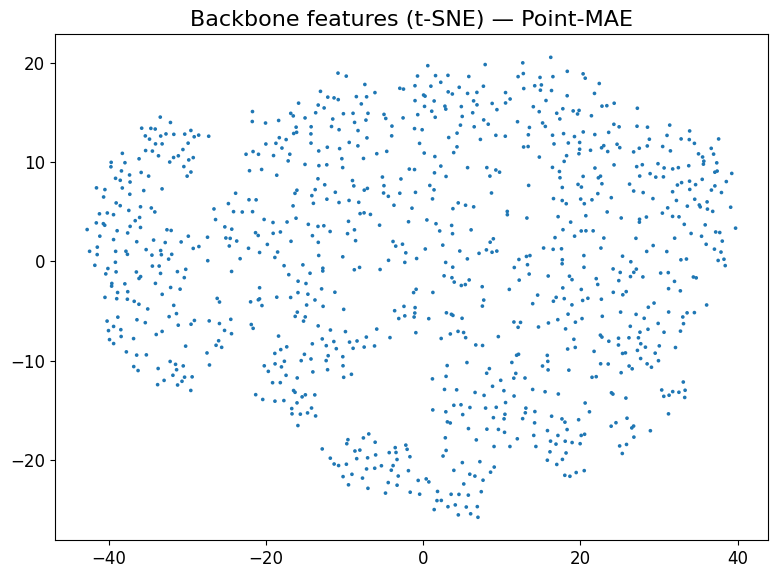

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_default\Point-MAE_tsne_area.png


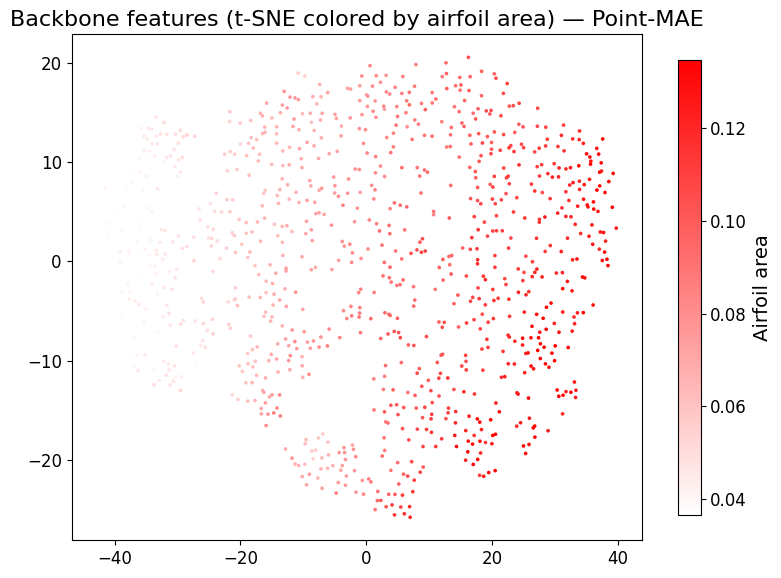

[Point-MAE] NACA kinds — 4-digit: 489, 5-digit: 511, unknown: 0
[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_default\Point-MAE_tsne_camber.png


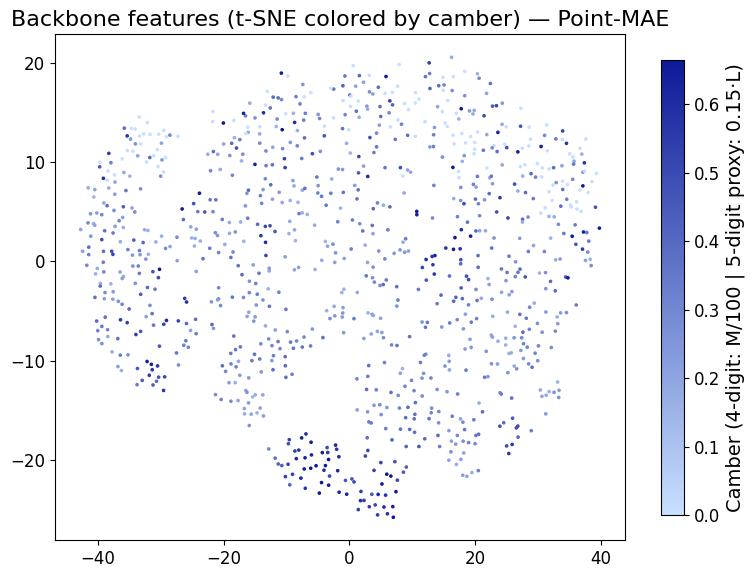

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_default\Point-MAE_tsne_thickness.png


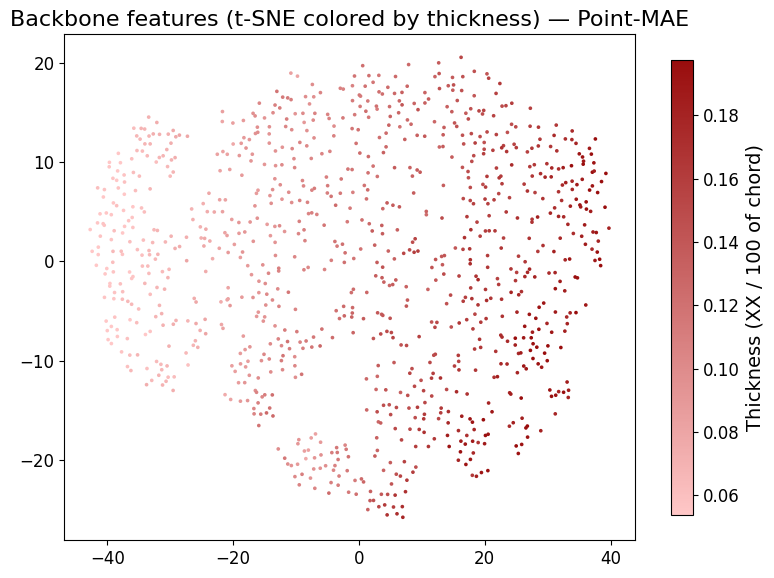

[Point-MAE] Plotting t-SNE colored by area, camber, and thickness.
[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_default\Point-MAE_tsne_area_camber_thickness.png


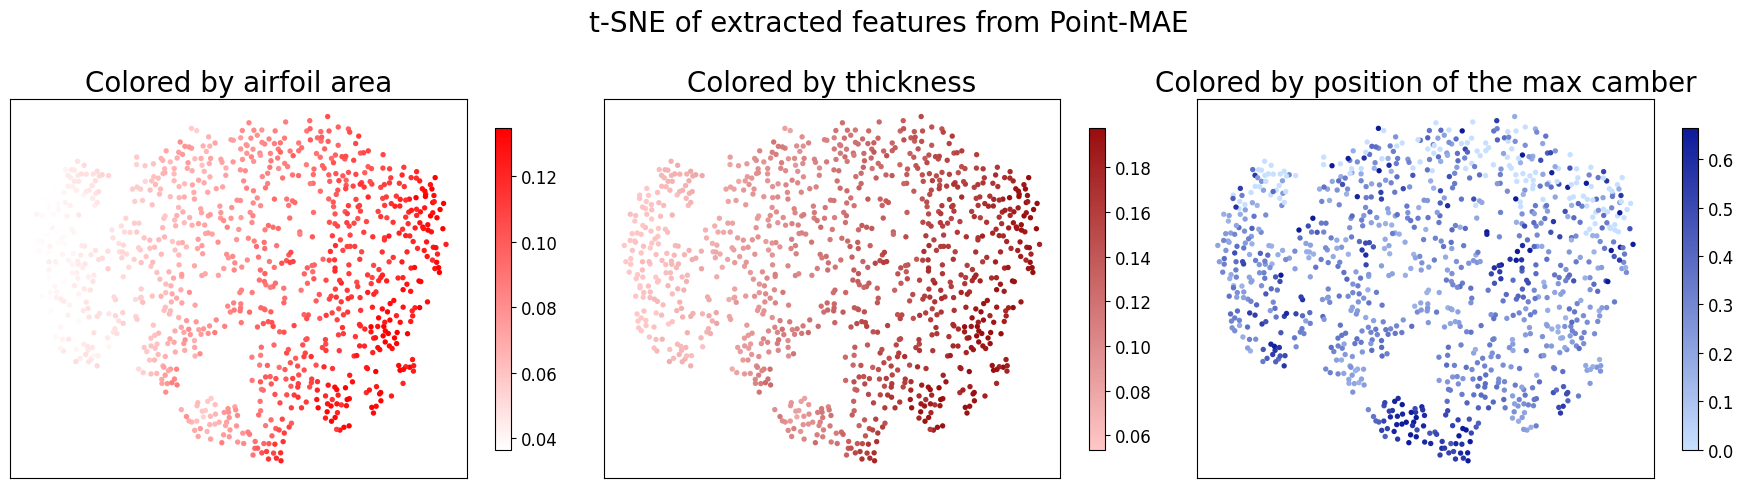

In [7]:
result = analyse_pointMAE_backbone2(model=model, device=device, class_choice = ["default"], data_folder = "shapenet_like_out3", npoints=1024, batch_size=32, plots=True)

# Centered

In [7]:
result = analyse_pointMAE_backbone2(model=model, device=device, class_choice = "centered", data_folder = "shapenet_like_out3", plots=False)

1000
[PointMAE-pretrain] features: (1000, 1152), labels: (1000, 1)
Saved features to: c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_c\PointMAE_pretrain_c_features.csv


# Normalized

1000
[PointMAE-pretrain] features: (1000, 1152), labels: (1000, 1)
Saved features to: c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_normalized\PointMAE_pretrain_normalized_features.csv
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.000s...
[t-SNE] Computed neighbors for 1000 samples in 0.020s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 0.001009
[t-SNE] KL divergence after 250 iterations with early exaggeration: 64.085289
[t-SNE] KL divergence after 1000 iterations: 1.041968
[PointMAE_pretrain] t-SNE computed: X2=(1000, 2)
[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_normalized\PointMAE_pretrain_tsne_embeddings.png
[save] PointMAE_pretrain_tsne_embeddings.npy → c:\Users\romai\Desktop\3DFundation4Surogate

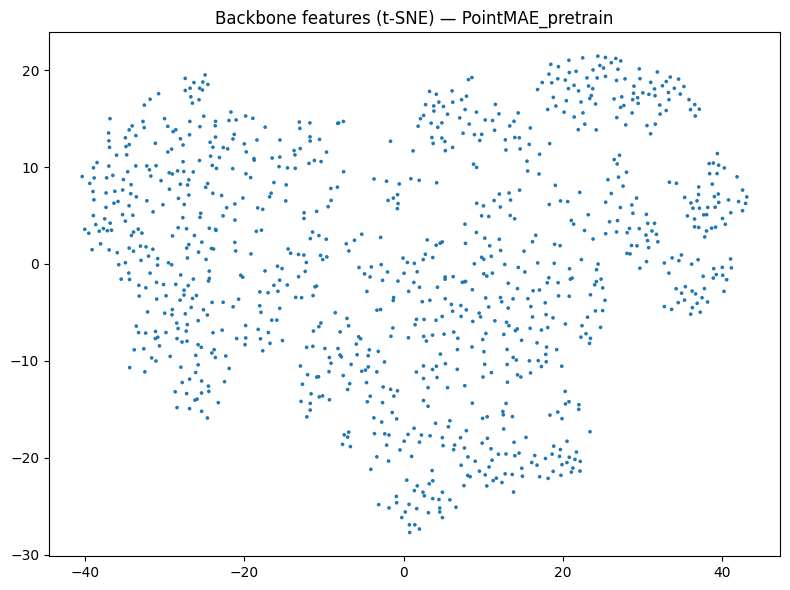

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_normalized\PointMAE_pretrain_tsne_area.png


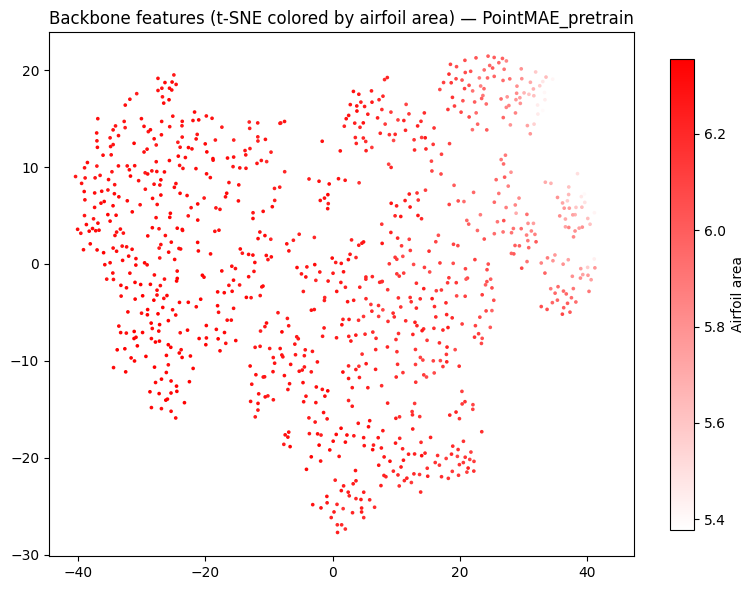

[PointMAE_pretrain] NACA kinds — 4-digit: 489, 5-digit: 511, unknown: 0
[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_normalized\PointMAE_pretrain_tsne_camber.png


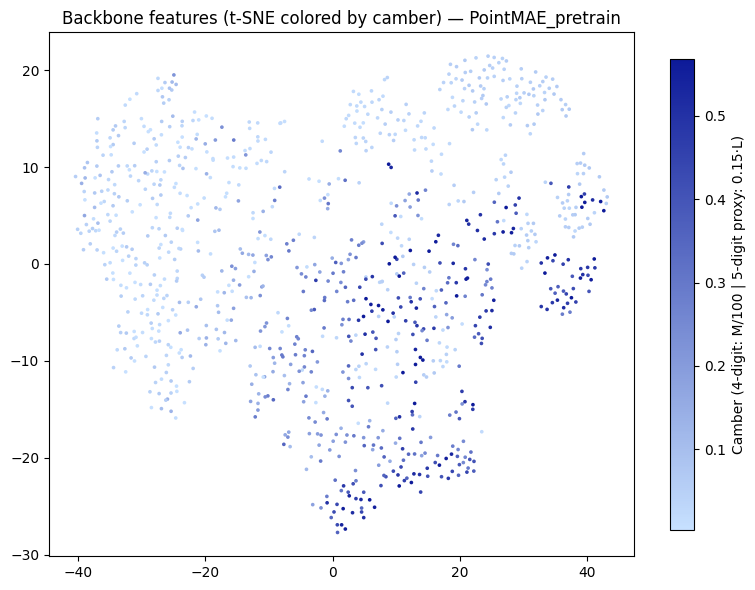

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_normalized\PointMAE_pretrain_tsne_thickness.png


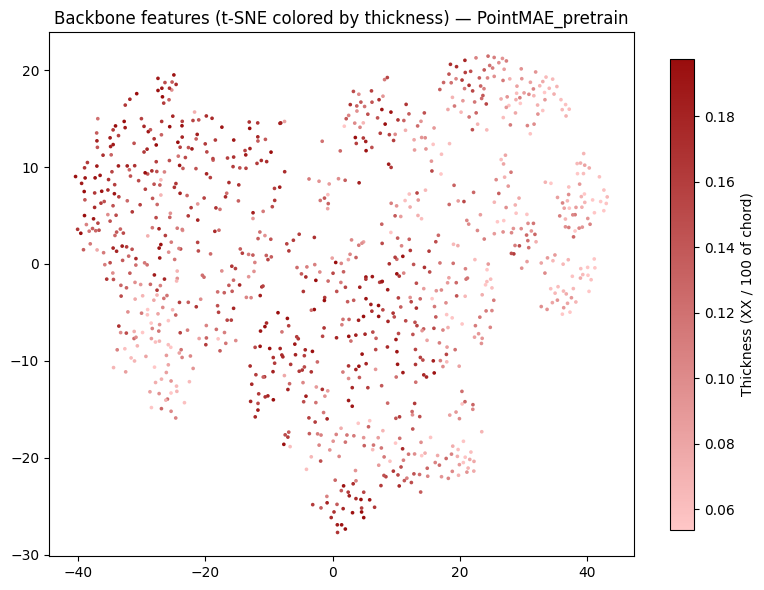

In [ ]:
result = analyse_pointMAE_backbone2(model=model, device=device, class_choice = ["normalized"], data_folder = "shapenet_like_out3", plots=True)

1000
[PointMAE-pretrain] features: (1000, 1152), labels: (1000, 1)
Saved features to: c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_Extruded_normalized_thin_uniform\PointMAE_pretrain_Extruded_normalized_thin_uniform_features.csv
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.000s...
[t-SNE] Computed neighbors for 1000 samples in 0.021s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 0.002239
[t-SNE] KL divergence after 250 iterations with early exaggeration: 64.983414
[t-SNE] KL divergence after 1000 iterations: 1.460910
[PointMAE_pretrain] t-SNE computed: X2=(1000, 2)
[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_Extruded_normalized_thin_uniform\PointMAE_pretrain_tsne_embeddings.png
[save] PointMAE_pretrain

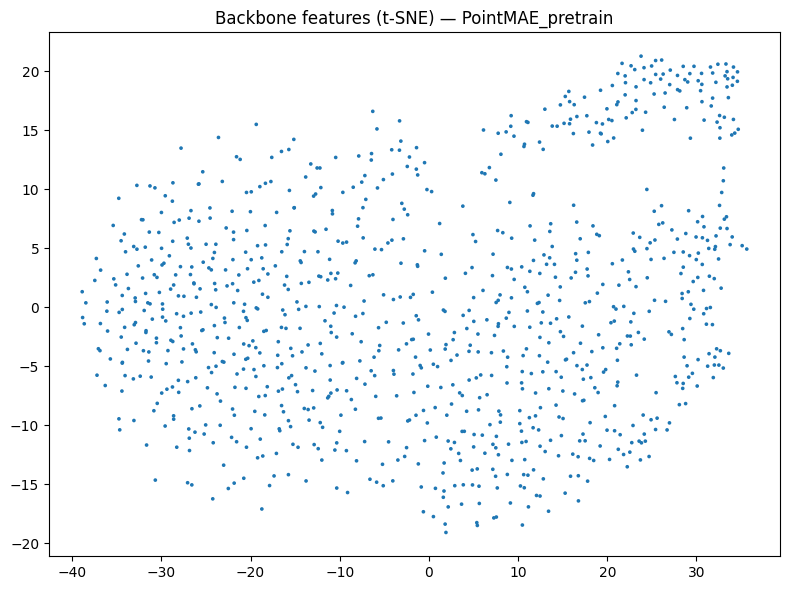

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_Extruded_normalized_thin_uniform\PointMAE_pretrain_tsne_area.png


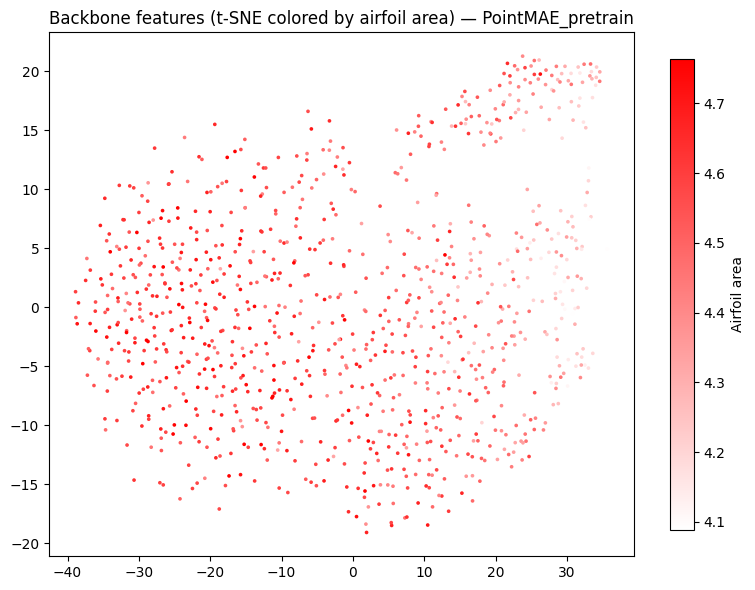

[PointMAE_pretrain] NACA kinds — 4-digit: 489, 5-digit: 511, unknown: 0
[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_Extruded_normalized_thin_uniform\PointMAE_pretrain_tsne_camber.png


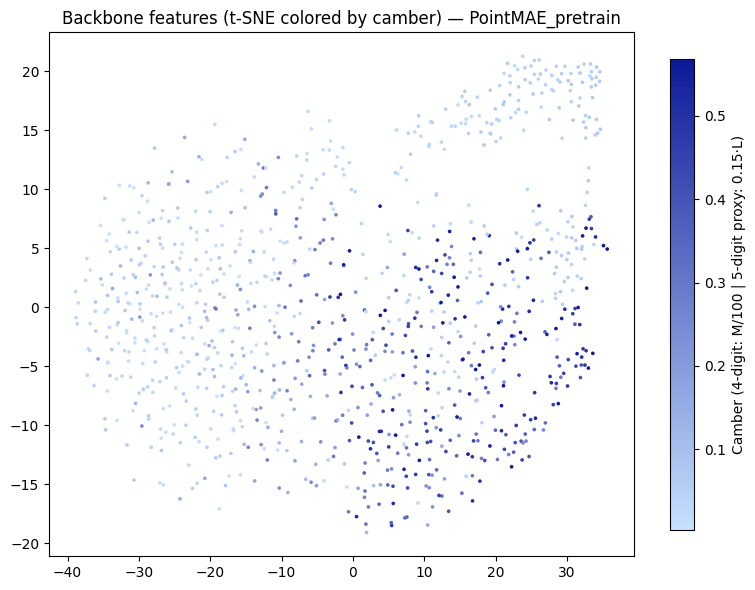

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_Extruded_normalized_thin_uniform\PointMAE_pretrain_tsne_thickness.png


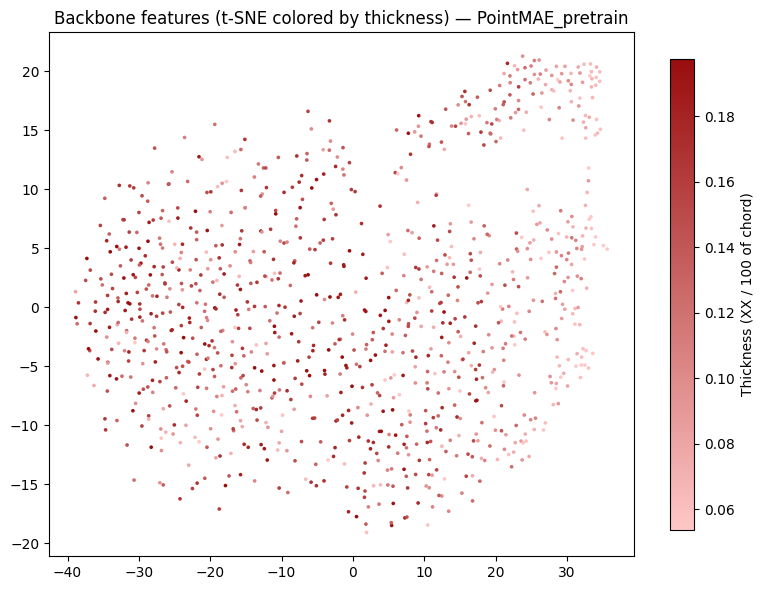

In [ ]:
result = analyse_pointMAE_backbone2(model=model, device=device, class_choice = ["Extruded_normalized_thin_uniform"], data_folder = "shapenet_like_out3", plots=True)

1000
[PointMAE-pretrain] features: (1000, 1152), labels: (1000, 1)
Saved features to: c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_torus_normalized\PointMAE_pretrain_torus_normalized_features.csv
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.000s...
[t-SNE] Computed neighbors for 1000 samples in 0.019s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 0.002084
[t-SNE] KL divergence after 250 iterations with early exaggeration: 67.994316
[t-SNE] KL divergence after 1000 iterations: 1.730343
[PointMAE_pretrain] t-SNE computed: X2=(1000, 2)
[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_torus_normalized\PointMAE_pretrain_tsne_embeddings.png
[save] PointMAE_pretrain_tsne_embeddings.npy → c:\Users\romai\Desktop\3D

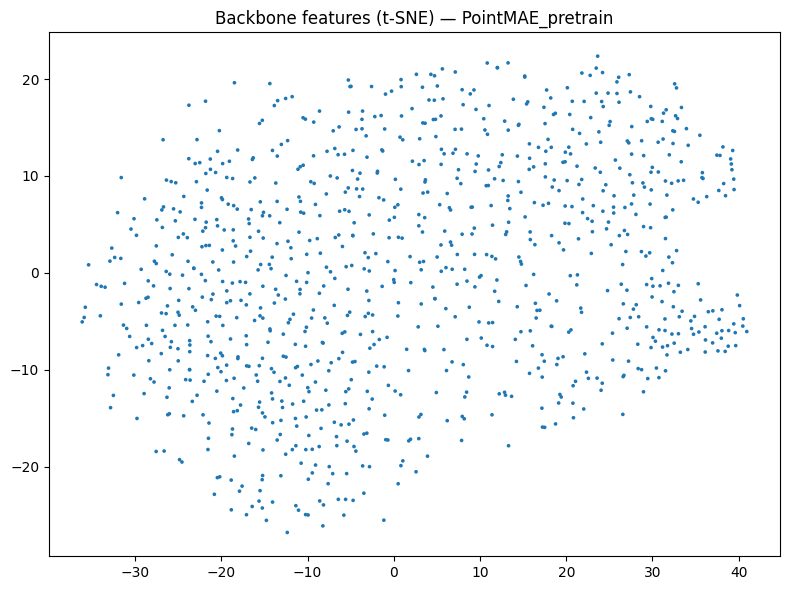

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_torus_normalized\PointMAE_pretrain_tsne_area.png


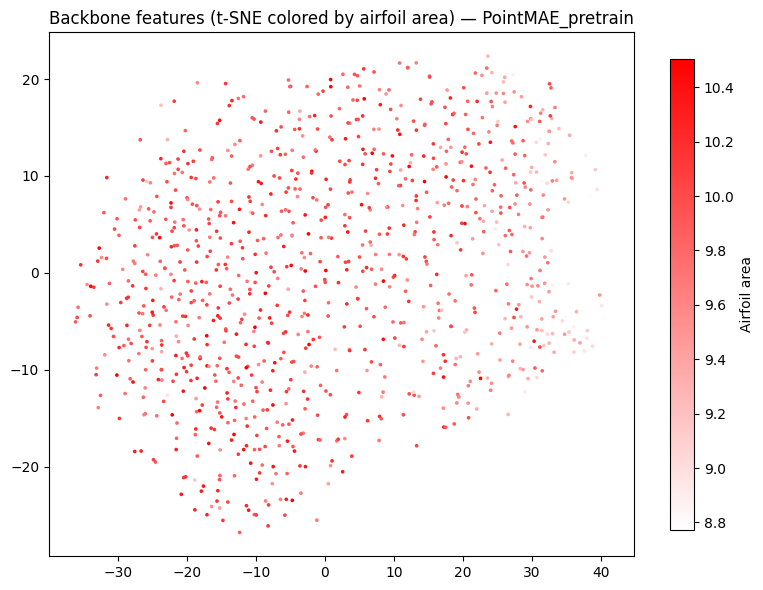

[PointMAE_pretrain] NACA kinds — 4-digit: 489, 5-digit: 511, unknown: 0
[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_torus_normalized\PointMAE_pretrain_tsne_camber.png


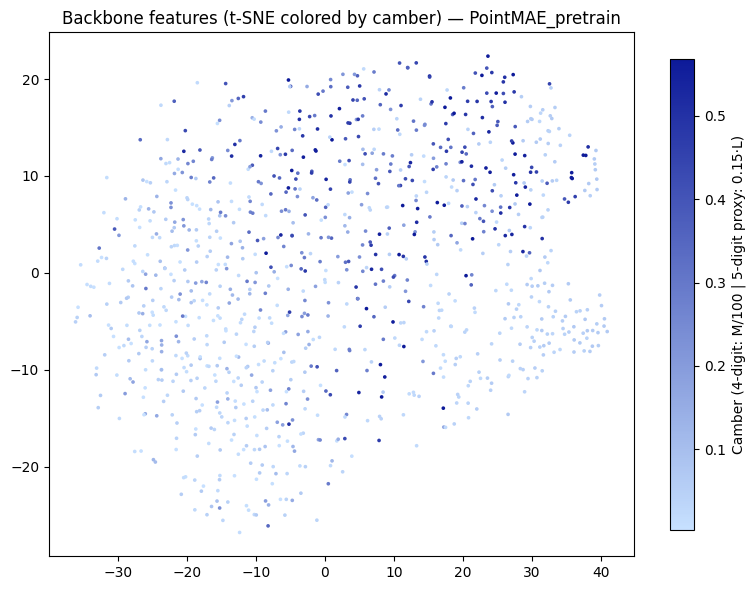

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_torus_normalized\PointMAE_pretrain_tsne_thickness.png


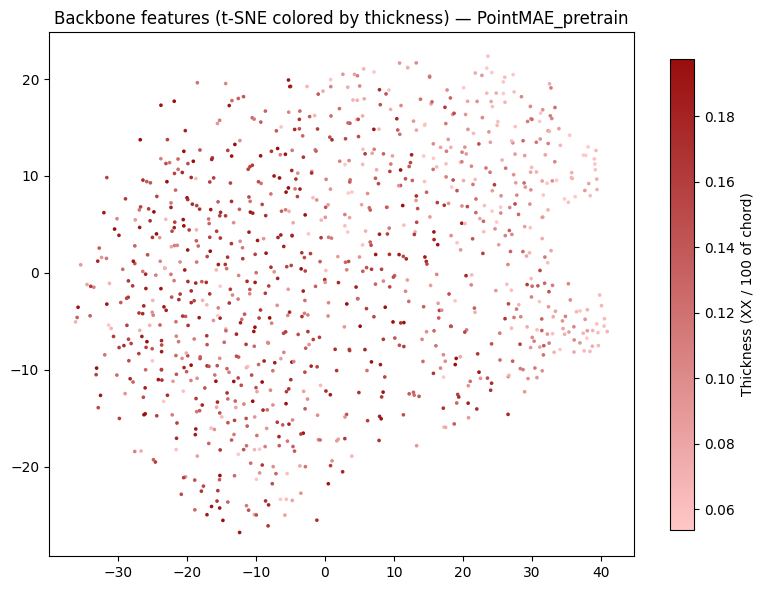

In [ ]:
result = analyse_pointMAE_backbone2(model=model, device=device, class_choice = ["torus_normalized"], data_folder = "shapenet_like_out3", plots=True)

1000
[PointMAE-pretrain] features: (1000, 1152), labels: (1000, 1)
Saved features to: c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_OT_2D\PointMAE_pretrain_OT_2D_features.csv
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.002s...
[t-SNE] Computed neighbors for 1000 samples in 0.024s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 0.000345
[t-SNE] KL divergence after 250 iterations with early exaggeration: 64.458763
[t-SNE] KL divergence after 1000 iterations: 1.294928
[PointMAE_pretrain] t-SNE computed: X2=(1000, 2)
[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_OT_2D\PointMAE_pretrain_tsne_embeddings.png
[save] PointMAE_pretrain_tsne_embeddings.npy → c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFund

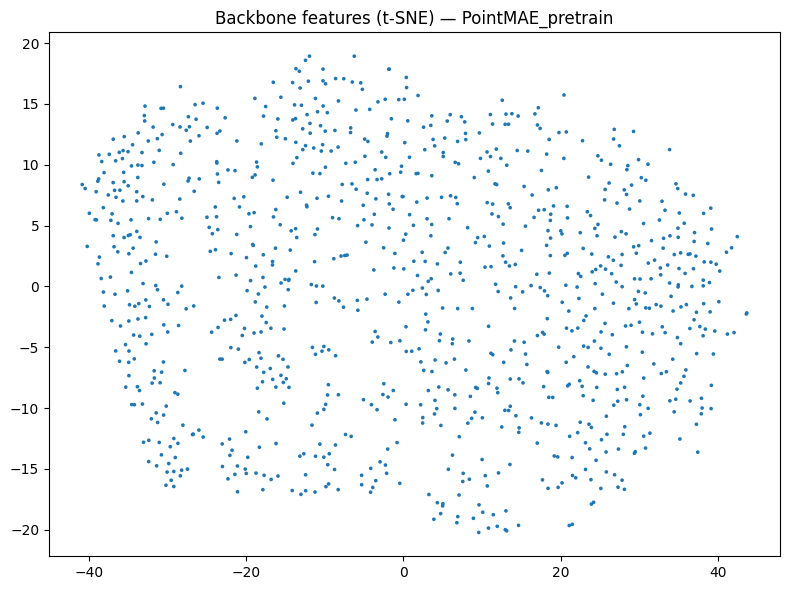

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_OT_2D\PointMAE_pretrain_tsne_area.png


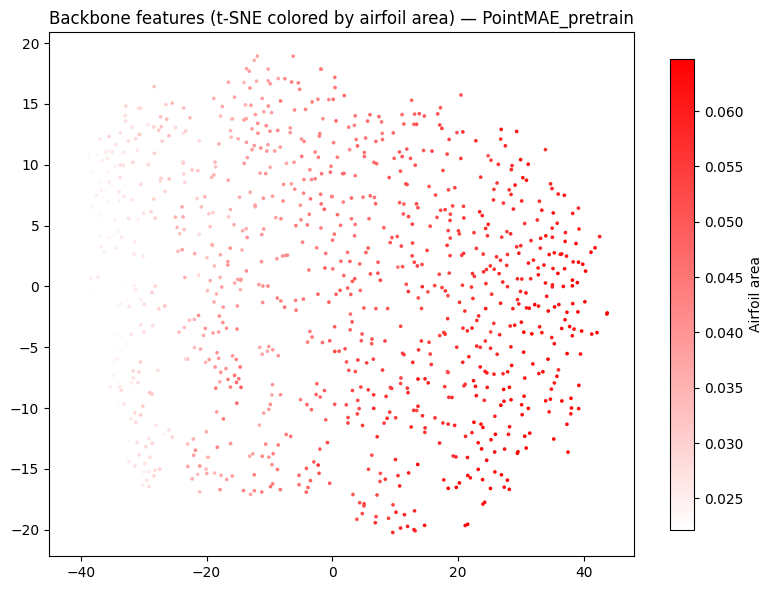

[PointMAE_pretrain] NACA kinds — 4-digit: 489, 5-digit: 511, unknown: 0
[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_OT_2D\PointMAE_pretrain_tsne_camber.png


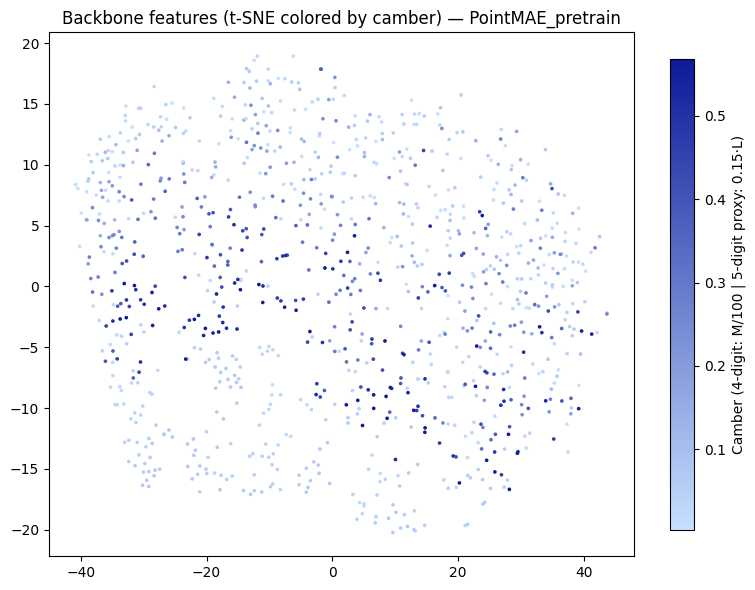

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_OT_2D\PointMAE_pretrain_tsne_thickness.png


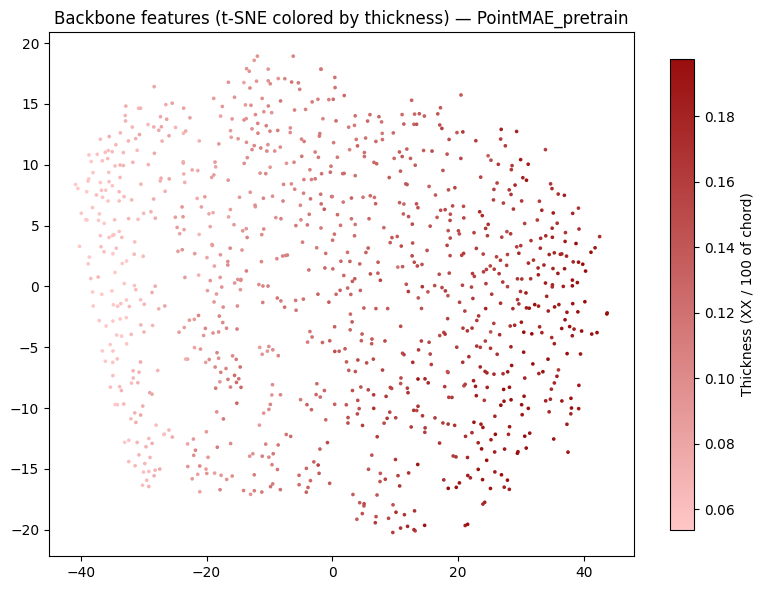

In [ ]:

result = analyse_pointMAE_backbone2(model=model, device=device, class_choice = ["OT_2D"], data_folder = "shapenet_like_out3", plots=True)

1000
[PointMAE-pretrain] features: (1000, 1152), labels: (1000, 1)
Saved features to: c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_OT_3D\PointMAE_pretrain_OT_3D_features.csv
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.000s...
[t-SNE] Computed neighbors for 1000 samples in 0.026s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 0.000691
[t-SNE] KL divergence after 250 iterations with early exaggeration: 64.547791
[t-SNE] KL divergence after 1000 iterations: 1.542754
[PointMAE_pretrain] t-SNE computed: X2=(1000, 2)
[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_OT_3D\PointMAE_pretrain_tsne_embeddings.png
[save] PointMAE_pretrain_tsne_embeddings.npy → c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFund

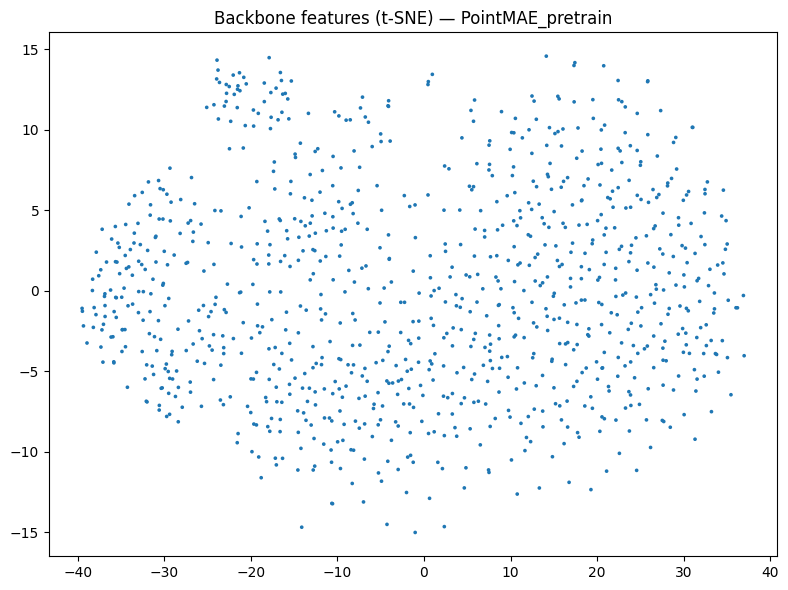

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_OT_3D\PointMAE_pretrain_tsne_area.png


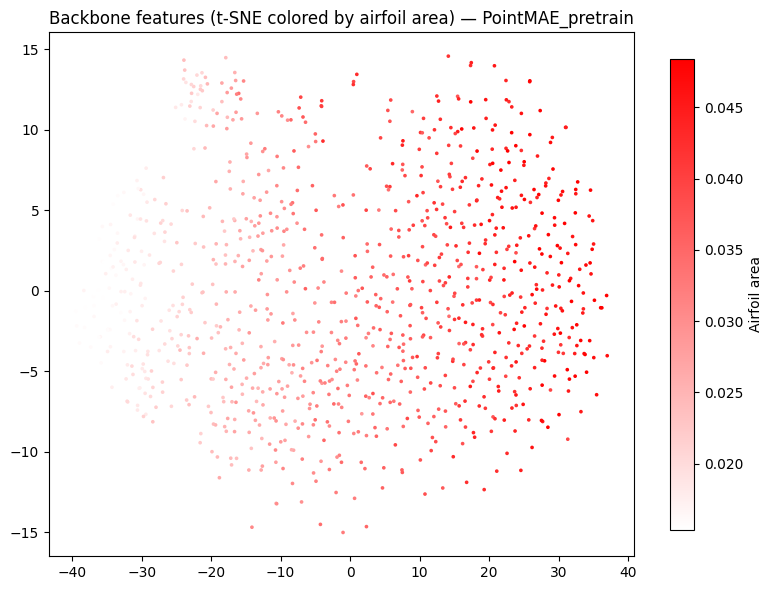

[PointMAE_pretrain] NACA kinds — 4-digit: 489, 5-digit: 511, unknown: 0
[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_OT_3D\PointMAE_pretrain_tsne_camber.png


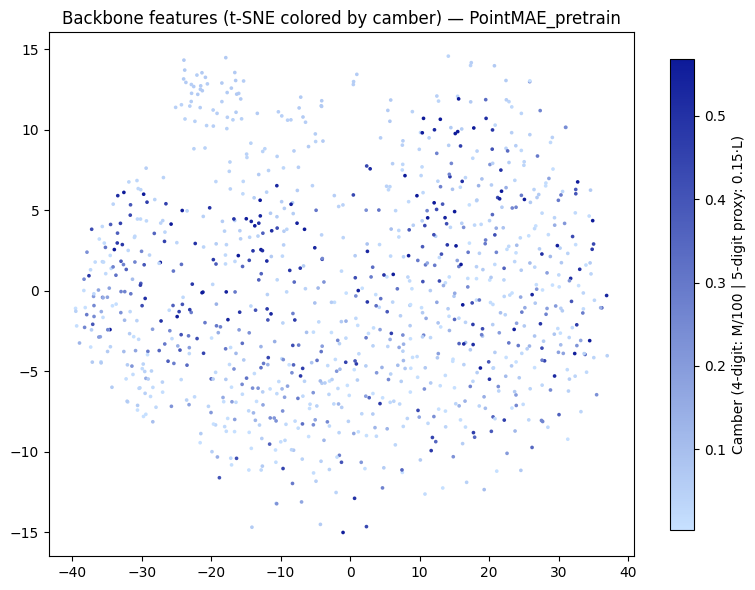

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_OT_3D\PointMAE_pretrain_tsne_thickness.png


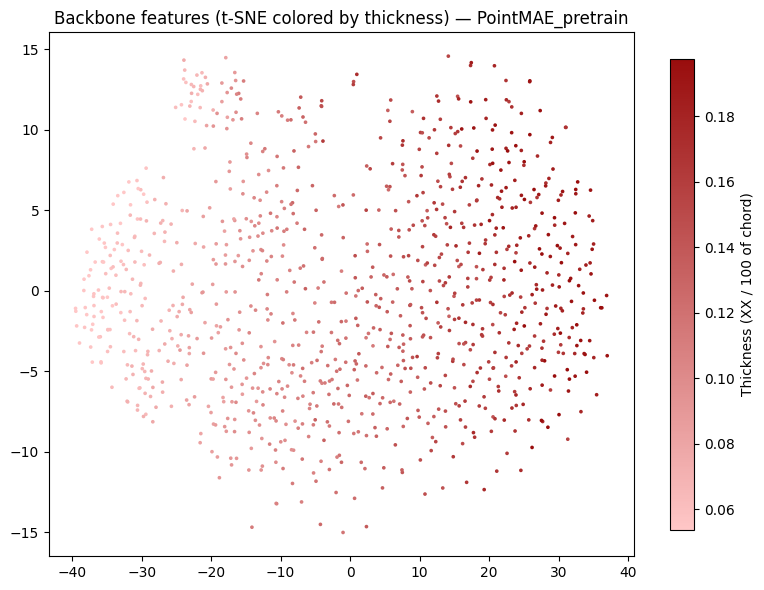

In [ ]:

result = analyse_pointMAE_backbone2(model=model, device=device, class_choice = ["OT_3D"], data_folder = "shapenet_like_out3", plots=True)

# Baseline: extract feature from the real dataset 

In [ ]:
class_choice = [
    "Airplane",
    "Bag",
    "Cap",
    "Car",
    "Chair",
    "Earphone",
    "Guitar",
    "Knife",
    "Lamp",
    "Laptop",
    "Motorbike",
    "Mug",
    "Pistol",
    "Rocket",
    "Skateboard",
    "Table"
]

result = analyse_pointMAE_backbone2(model=model, device=device, class_choice = class_choice, data_folder = "shapenetcore_partanno_segmentation_benchmark_v0", plots=False, shapenenet = True)

2874
[PointMAE-pretrain] features: (2874, 1152), labels: (2874, 1)
Saved features to: c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\PointMAE_pretrain_Airplane\PointMAE_pretrain_Airplane_features.csv


[t-SNE] Computing 2D projection on extracted features...


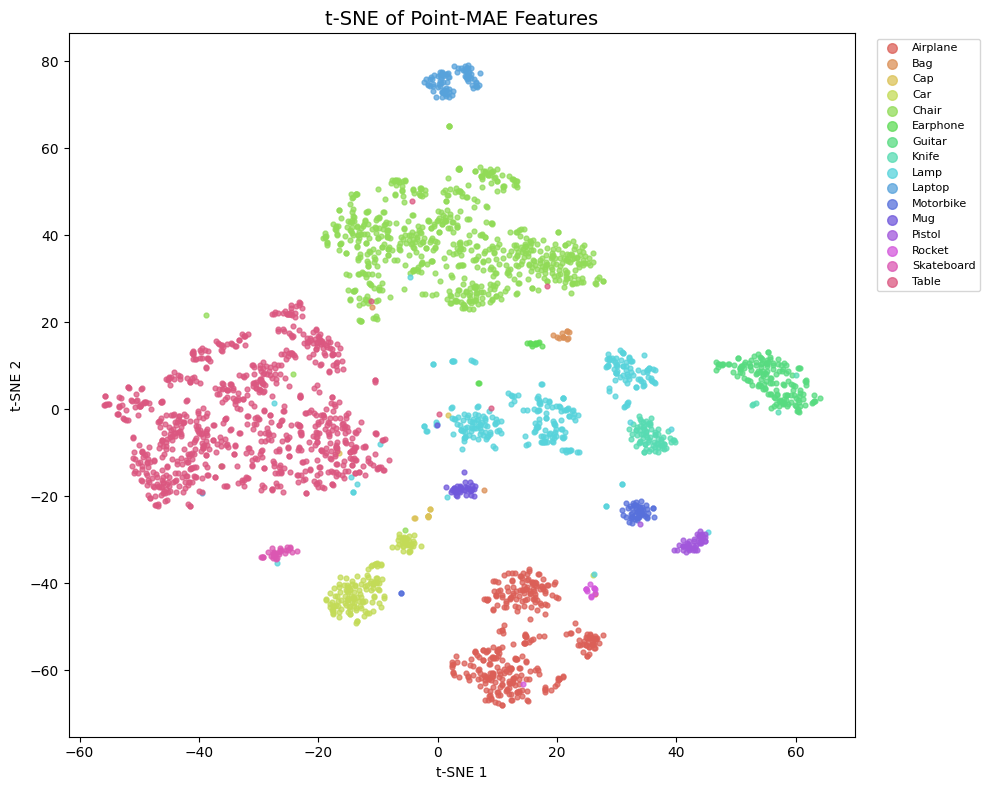

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

X = result["features"]   # numpy array (N, C)
y = result["labels"].squeeze()     # numpy array (N,)
print("[t-SNE] Computing 2D projection on extracted features...")
X_2d = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init="pca"
).fit_transform(X)

# Colors per category
unique_labels = np.unique(y)
palette = sns.color_palette("hls", len(unique_labels))

plt.figure(figsize=(10, 8))
for i, lab in enumerate(unique_labels):
    idx = y == lab
    plt.scatter(
        X_2d[idx, 0],
        X_2d[idx, 1],
        s=12,
        alpha=0.75,
        color=palette[i],
        label=class_choice[lab]
    )

plt.title("t-SNE of Point-MAE Features", fontsize=14)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(
    markerscale=2,
    fontsize=8,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()
